# STLRocket: STL Formulas as Random Convolutional Kernels

This notebook implements a ROCKET-inspired pipeline where **STL formulas replace random convolutional kernels**.

**Core idea:**  
For each random STL formula φ and each time series x, compute the **robustness trace** ρ(φ, x, t) — the quantitative satisfaction of φ at every time step. This trace plays the role of a convolutional feature map. Summary statistics are extracted per trace as quantiles of the robustness distribution.


In [221]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV, LogisticRegressionCV, LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from matplotlib.colors import TwoSlopeNorm
import numpy as np
from sklearn.metrics import accuracy_score
from scipy.optimize import milp, LinearConstraint, Bounds
from aeon.datasets import load_classification
from stlkernel.distribution_formulae import F0
from torcheck import stl
torch.manual_seed(42)
np.random.seed(42)

In [222]:
ds_name = "BasicMotions"
X_tr_np, y_tr = load_classification(ds_name, split="TRAIN")
X_te_np, y_te = load_classification(ds_name, split="TEST")

/tmp/ipykernel_361303/1495118420.py:2: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_tr_np, y_tr = load_classification(ds_name, split="TRAIN")
/tmp/ipykernel_361303/1495118420.py:3: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_te_np, y_te = load_classification(ds_name, split="TEST")


In [223]:
def extract_features(X: torch.Tensor, formulas: list) -> np.ndarray:
    features = [
        phi.quantitative(X, evaluate_at_all_times=False, normalize=False).float()
        for phi in formulas
    ]

    return torch.stack(features, dim=1)

class TensorStandardScaler:
    def __init__(self, eps=1e-8):
        self.mean, self.std, self.eps = None, None, eps

    def fit(self, X: torch.Tensor):
        self.mean = X.mean(dim=(0, 2), keepdim=True)
        self.std = X.std(dim=(0, 2), keepdim=True)
        return self

    def transform(self, X: torch.Tensor):
        return (X - self.mean) / (self.std + self.eps)

    def fit_transform(self, X: torch.Tensor):
        return self.fit(X).transform(X)


In [259]:
N_FORMULAS = 500
N, V, T = X_tr_np.shape
print(N)

scaler = TensorStandardScaler()

X_tr_t = scaler.fit_transform(torch.from_numpy(X_tr_np))
X_te_t = scaler.transform(torch.from_numpy(X_te_np))

v_min = X_tr_t.amin(dim=(0, 2))
v_max = X_tr_t.amax(dim=(0, 2))

formulas = F0(n_vars=V, v_min=v_min, v_max=v_max, t_max=T - 1, depth_max=2, seed=100).sample(N_FORMULAS)

X_tr_feats = extract_features(X_tr_t, formulas)
X_te_feats = extract_features(X_te_t, formulas)

40


In [260]:
model = LogisticRegressionCV(
    Cs=np.logspace(-5, 1, 20),
    l1_ratios=[1.0],
    fit_intercept=False, # Since it is a concept based model, it must not decide if the formulae express 0 rob
    solver='saga',
    max_iter=10000,
    class_weight='balanced',
    use_legacy_attributes=False
)

model.fit(X_tr_feats, y_tr)
model.score(X_te_feats, y_te)

0.975

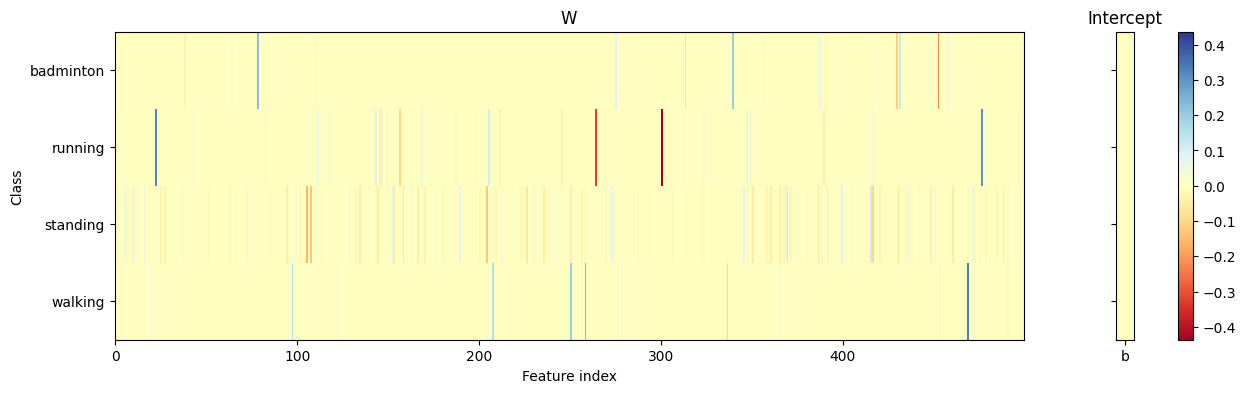

In [261]:
W = model.coef_                                       # (K, M)
b = model.intercept_                                  # (K,)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4),
                                gridspec_kw={"width_ratios": [W.shape[1], 1*10]})

vmax = np.abs(W).max()
if vmax < np.abs(b).max():
    vmax = np.abs(b).max()

norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

ax1.imshow(W, aspect="auto", cmap="RdYlBu", norm=norm, interpolation="none")
ax1.set_xlabel("Feature index")
ax1.set_ylabel("Class")
ax1.set_yticks(range(len(model.classes_)))
ax1.set_yticklabels(model.classes_)
ax1.set_title("W")

im = ax2.imshow(b.reshape(-1, 1), aspect="auto", cmap="RdYlBu", norm=norm, interpolation="none")
ax2.set_xlabel("")
ax2.set_xticks([0])
ax2.set_xticklabels(["b"])
ax2.set_yticks(range(len(model.classes_)))
ax2.set_yticklabels([])
ax2.set_title("Intercept")

fig.colorbar(im, ax=[ax1, ax2], fraction=0.02, pad=0.04)
plt.show()

In [262]:
# Keep only features the model actually uses
non_zero_features = (W != 0.0).any(axis=0)              # (M,)
W_sel = W #[:, non_zero_features]                       # (K, M_sel)

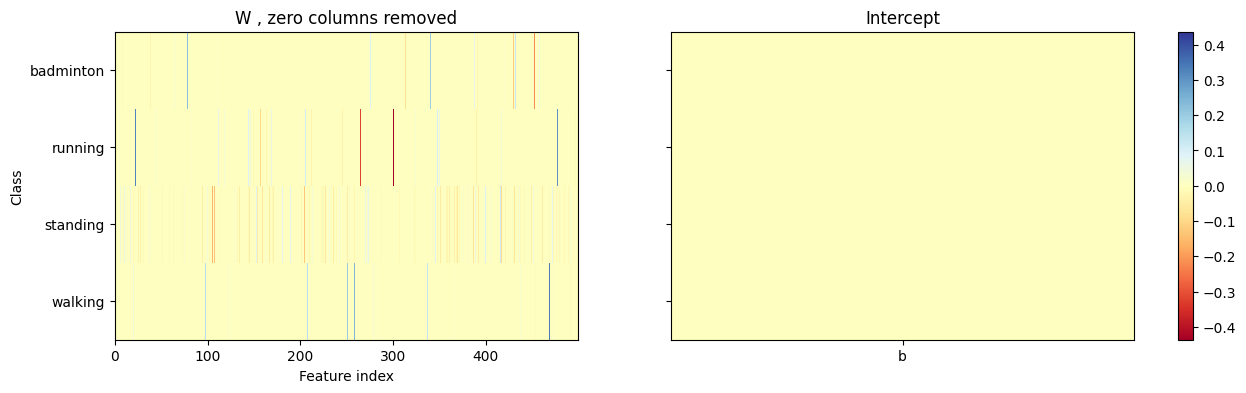

In [263]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4),
                                gridspec_kw={"width_ratios": [W_sel.shape[1], W_sel.shape[1]]})

vmax = np.abs(W_sel).max()
if vmax < np.abs(b).max():
    vmax = np.abs(b).max()

norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

ax1.imshow(W_sel, aspect="auto", cmap="RdYlBu", norm=norm, interpolation="none")
ax1.set_xlabel("Feature index")
ax1.set_ylabel("Class")
ax1.set_yticks(range(len(model.classes_)))
ax1.set_yticklabels(model.classes_)
ax1.set_title("W , zero columns removed")

im = ax2.imshow(b.reshape(-1, 1), aspect="auto", cmap="RdYlBu", norm=norm, interpolation="none")
ax2.set_xlabel("")
ax2.set_xticks([0])
ax2.set_xticklabels(["b"])
ax2.set_yticks(range(len(model.classes_)))
ax2.set_yticklabels([])
ax2.set_title("Intercept")

fig.colorbar(im, ax=[ax1, ax2], fraction=0.02, pad=0.04)
plt.show()

fig.savefig("fig")

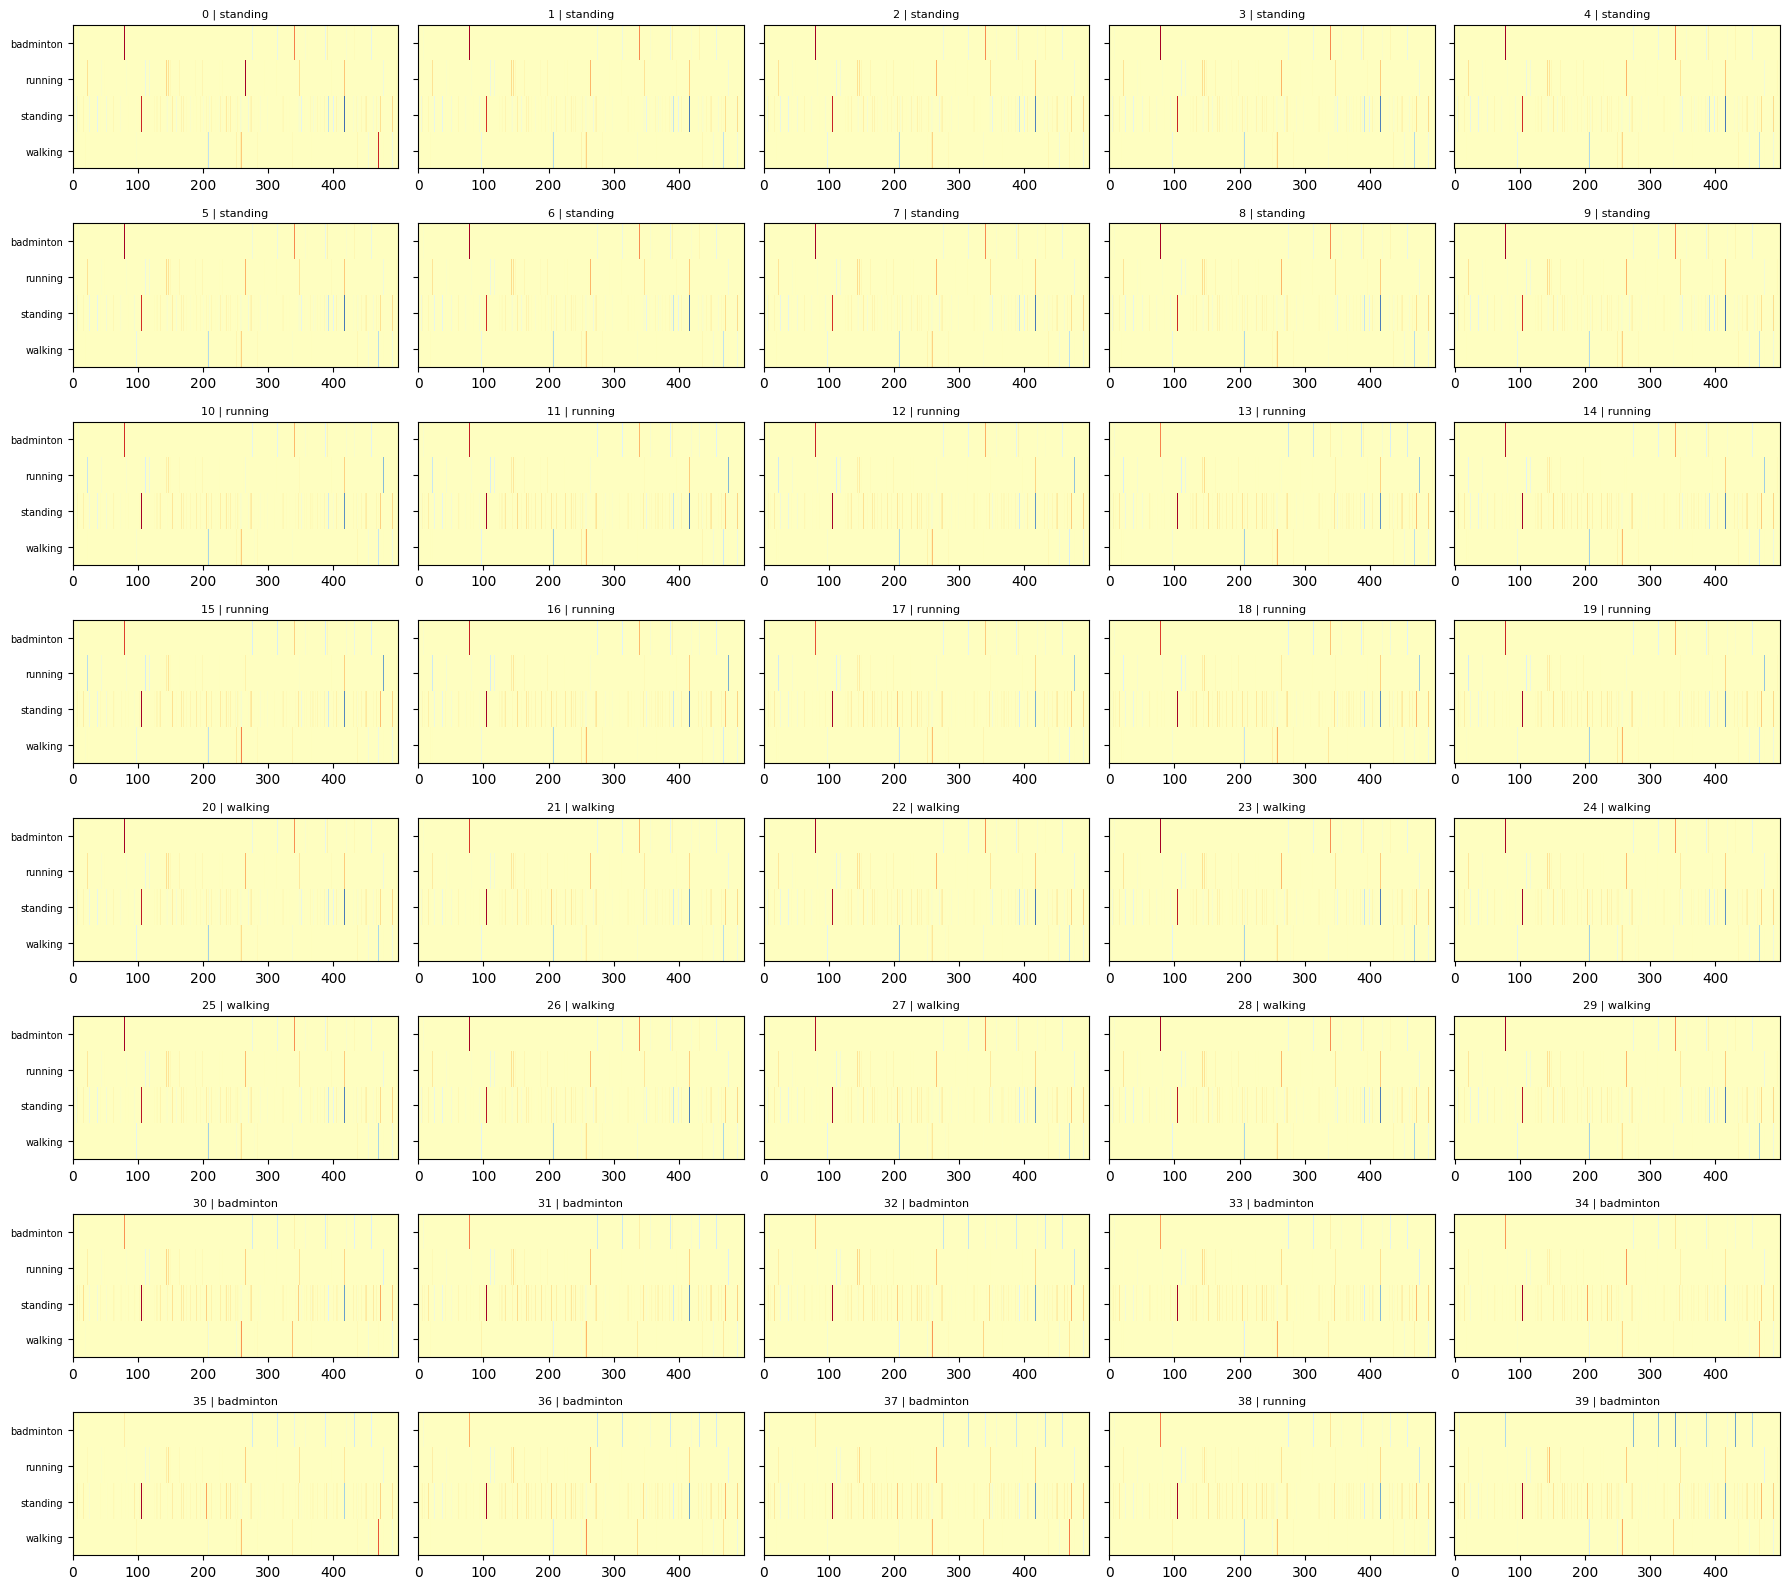

In [264]:
n = X_te_feats.shape[0]
ncols = 5
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 2))
axes = axes.flatten()

for i in range(n):
    x = X_te_feats[i].numpy() 
    y_pred = model.predict(x.reshape(1, -1))[0]
    scores = W_sel * x[np.newaxis,]#, non_zero_features]            
    vmax = np.abs(scores).max()

    ax = axes[i]
    ax.imshow(scores, aspect="auto", cmap="RdYlBu",
              norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax),
              interpolation="none")
    ax.set_title(f"{i} | {y_pred}", fontsize=8)
    #ax.set_xticks(r)
    ax.set_yticks(range(len(model.classes_)))
    ax.set_yticklabels(model.classes_ if i % ncols == 0 else [], fontsize=7)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

#fig.suptitle("Local contribution scores — all test samples", fontweight="bold")
plt.tight_layout()
plt.savefig("XW")
plt.show()


In [274]:
K, M_sel = W_sel.shape
i = 17
x = X_te_feats[i].numpy()
y_pred = model.predict(x.reshape(1, -1))[0]
print("y_pred", y_pred)
print("y_true", y_te[i])

#x = x[non_zero_features]
class_idx = np.where(model.classes_ == y_pred)[0][0]
others = [k for k in range(K) if k != class_idx]

# Per-competitor weight differences D[k_row, j] = W[y, j] - W[k, j], shape (K-1, M_sel)
D = W_sel[class_idx] - W_sel[others]

# Bias differences, shape (K-1,)
delta_b = b[class_idx] - b[others]

# Per-formula training ranges on the selected (non-zero-weight) features.
# Computed once on raw (unstandardized) train features.
#v_min = X_tr_feats[:, non_zero_features].numpy().min(axis=0)   # (M_sel,)
#v_max = X_tr_feats[:, non_zero_features].numpy().max(axis=0)   # (M_sel,)

v_min = np.quantile(X_tr_feats[:, non_zero_features], 0.1, axis=0)
v_max = np.quantile(X_tr_feats[:, non_zero_features], 0.9, axis=0)

# Worst-case contribution of an UNSELECTED coordinate j to competitor k's margin:
#   if D[k,j] > 0  -> adversary picks v_min[j]
#   if D[k,j] < 0  -> adversary picks v_max[j]
#   if D[k,j] = 0  -> contributes 0
worst = np.where(D > 0, D * v_min, np.where(D < 0, D * v_max, 0.0))   # (K-1, M_sel)


# Sanity check: prediction must hold on the OBSERVED x (no abduction yet)
full_margins = D @ x + delta_b
print(f"Observed margins: {full_margins}")
assert np.all(full_margins > 0), "x is not classified as y_pred with positive margin"

epsilon = 0# max(1e-6, full_margins.min())
print(f"epsilon: {epsilon:.4f}")

# Abductive constraint, per competitor k:
#   sum_j (D[k,j] * x[j] - worst[k,j]) * p[j]  >=  epsilon - delta_b[k] - sum_j worst[k,j]
A = D * x[np.newaxis, :] - worst                     # (K-1, M_sel), non-negative entries
lb = epsilon - delta_b - worst.sum(axis=1)             # (K-1,)

result = milp(
    c=np.ones(M_sel),
    constraints=LinearConstraint(A, lb=lb, ub=np.inf),
    bounds=Bounds(0, 1),
    integrality=np.ones(M_sel),
)
assert result.success, result.message

selected = np.where(result.x > 0.5)[0]
print("Selected features:", selected)

# Verify the abductive guarantee: worst-case margin per competitor under p*
worst_case_margins = A @ result.x + delta_b + worst.sum(axis=1)
print("Worst-case margins after optimization:")
for idx, k in enumerate(others):
    print(f"  y={class_idx} vs k={k}: {worst_case_margins[idx]:.4f}")


y_pred running
y_true running


ValueError: operands could not be broadcast together with shapes (3,500) (214,) 

Predicted class: running
Scores per class: {np.str_('badminton'): np.float64(-0.96), np.str_('running'): np.float64(3.815), np.str_('standing'): np.float64(-7.402), np.str_('walking'): np.float64(0.207)}


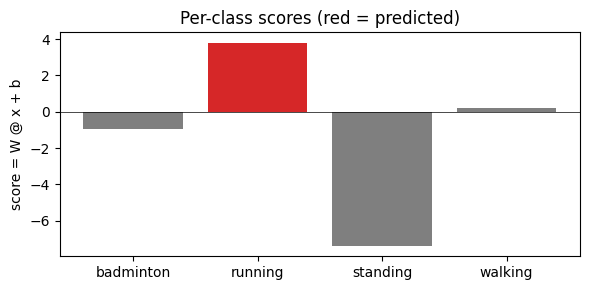


contrib_matrix shape: (3, 500)  (competitors x features)


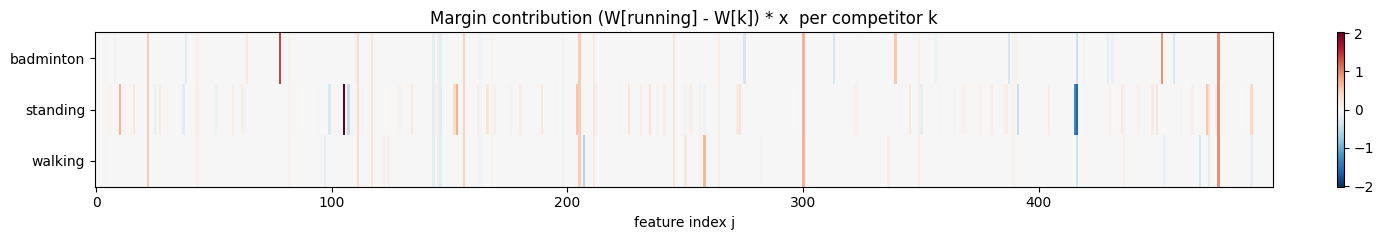


[Per-competitor] explanations:
  vs badminton     phi_78   contrib= +1.375  (supports)
  vs badminton     phi_476  contrib= +0.926  (supports)
  vs standing      phi_105  contrib= +2.018  (supports)
  vs standing      phi_476  contrib= +0.926  (supports)
  vs walking       phi_476  contrib= +0.931  (supports)
  vs walking       phi_300  contrib= +0.698  (supports)

[Global] top-2 formulas by sum of signed margin contributions:
  phi_476  sum contrib =  +2.783   per competitor: badminton: +0.93, standing: +0.93, walking: +0.93
  phi_300  sum contrib =  +2.075   per competitor: badminton: +0.69, standing: +0.69, walking: +0.70


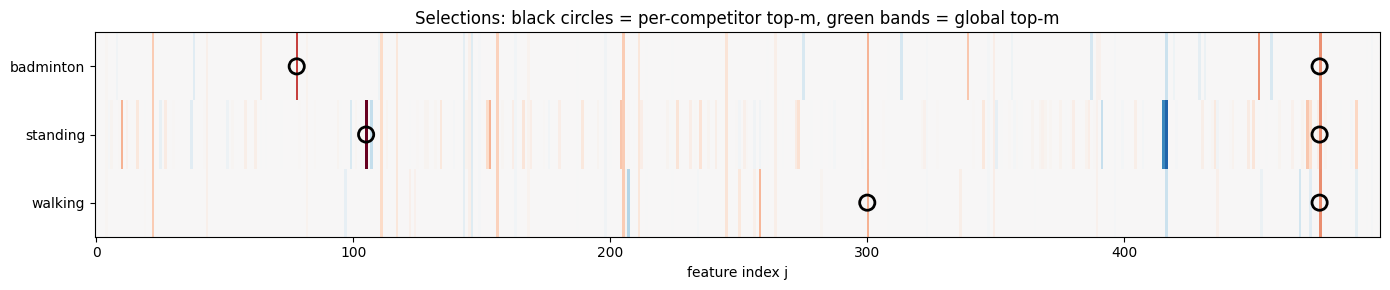

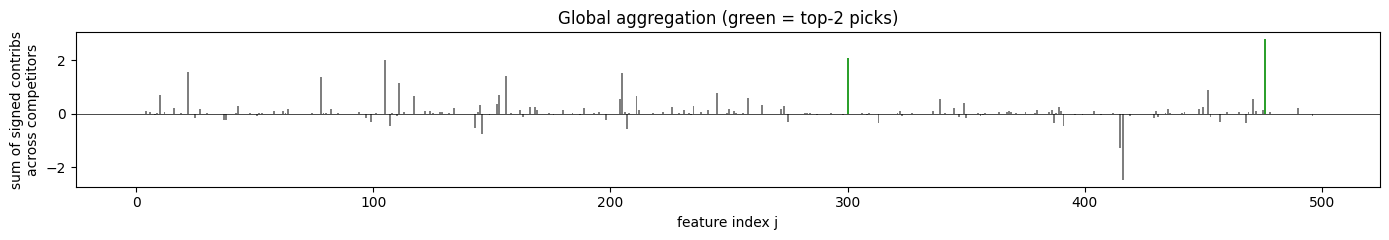


Per-competitor union [78, 105, 300, 476]  -> sufficient at zero? True
Global picks         [476, 300]  -> sufficient at zero? True


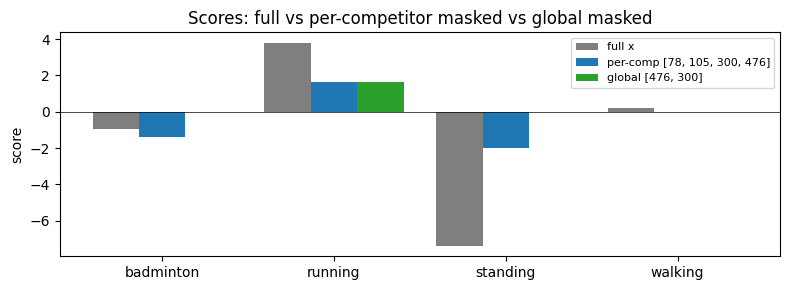

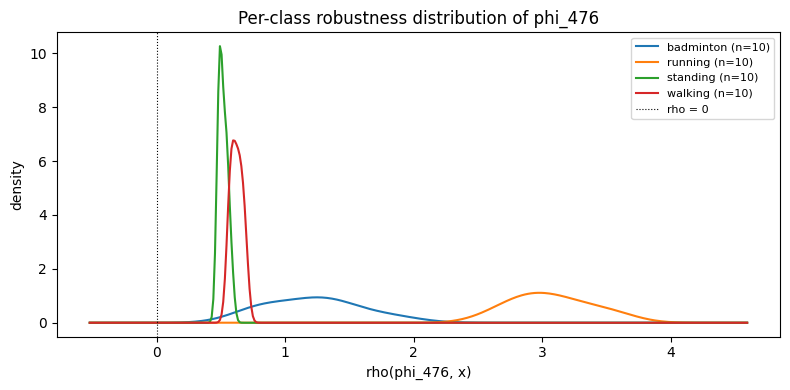

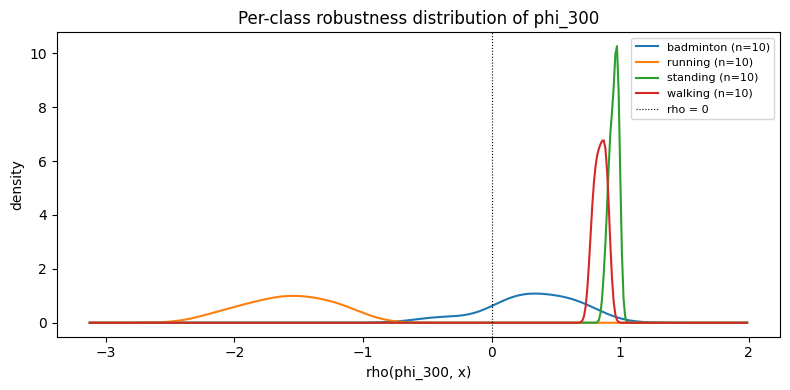

In [275]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- 0. Setup (assumes class_idx, x, W_sel, b, model already defined) ----------
x = np.asarray(x)
b = np.asarray(b)
scores = W_sel @ x + b
others = [k for k in range(len(model.classes_)) if k != class_idx]
m = 2

print(f"Predicted class: {model.classes_[class_idx]}")
print(f"Scores per class: {dict(zip(model.classes_, np.round(scores, 3)))}")

# --- 1. Visualize raw scores ---------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 3))
colors = ["tab:red" if k == class_idx else "tab:gray" for k in range(len(model.classes_))]
ax.bar(model.classes_, scores, color=colors)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("score = W @ x + b")
ax.set_title("Per-class scores (red = predicted)")
plt.tight_layout(); plt.show()

# --- 2. Compute per-competitor margin contributions ----------------------------
# contrib_matrix[row, j] = (W[y, j] - W[k, j]) * x[j]   for the row's competitor k
contrib_matrix = np.stack([(W_sel[class_idx] - W_sel[k]) * x for k in others])
print(f"\ncontrib_matrix shape: {contrib_matrix.shape}  (competitors x features)")

# --- 3. Visualize the contribution matrix -------------------------------------
fig, ax = plt.subplots(figsize=(14, 2.5))
vmax = np.abs(contrib_matrix).max()
im = ax.imshow(
    contrib_matrix, aspect="auto", cmap="RdBu_r",
    norm=mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax),
    interpolation="none",
)
ax.set_yticks(range(len(others)))
ax.set_yticklabels([model.classes_[k] for k in others])
ax.set_xlabel("feature index j")
ax.set_title(f"Margin contribution (W[{model.classes_[class_idx]}] - W[k]) * x  per competitor k")
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout(); plt.show()

# --- 4a. PER-COMPETITOR top-m: pick m features per competitor by contribution --
per_competitor_picks = {}
for row, k in enumerate(others):
    contrib = contrib_matrix[row]
    order = np.argsort(-contrib)
    picked = order[:m]
    per_competitor_picks[model.classes_[k]] = [
        (int(j), float(contrib[j]), "supports" if contrib[j] > 0 else "threatens")
        for j in picked
    ]

print("\n[Per-competitor] explanations:")
for k_label, lst in per_competitor_picks.items():
    for j, c, role in lst:
        print(f"  vs {k_label:<12s}  phi_{j:<3d}  contrib={c:+7.3f}  ({role})")

per_competitor_union = sorted({j for v in per_competitor_picks.values() for j, _, _ in v})

# --- 4b. GLOBAL top-m: aggregate signed contributions across competitors -------
global_score = contrib_matrix.sum(axis=0)             # (M_sel,) sum of signed contribs
global_order = np.argsort(-global_score)
global_picks = global_order[:m].tolist()

print(f"\n[Global] top-{m} formulas by sum of signed margin contributions:")
for j in global_picks:
    per_comp = {model.classes_[k]: float(contrib_matrix[r, j])
                for r, k in enumerate(others)}
    print(f"  phi_{j:<3d}  sum contrib = {global_score[j]:+7.3f}   per competitor: "
          + ", ".join(f"{lbl}: {v:+5.2f}" for lbl, v in per_comp.items()))

# --- 5. Visualize the contribution matrix with both selections highlighted -----
fig, ax = plt.subplots(figsize=(14, 3))
ax.imshow(
    contrib_matrix, aspect="auto", cmap="RdBu_r",
    norm=mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax),
    interpolation="none",
)
# black circles for per-competitor picks (one per row)
for row, k in enumerate(others):
    for j, _, _ in per_competitor_picks[model.classes_[k]]:
        ax.scatter(j, row, marker="o", s=120, facecolors="none",
                   edgecolors="black", linewidths=2,
                   label="per-competitor" if row == 0 and j == per_competitor_picks[model.classes_[others[0]]][0][0] else None)
# green vertical bands for global picks (span all rows)
#for j in global_picks:
#    ax.axvspan(j - 0.4, j + 0.4, color="tab:green", alpha=0.25)
ax.set_yticks(range(len(others)))
ax.set_yticklabels([model.classes_[k] for k in others])
ax.set_xlabel("feature index j")
ax.set_title("Selections: black circles = per-competitor top-m, green bands = global top-m")
plt.tight_layout(); plt.show()

# --- 6. Bar plot of the global aggregation -------------------------------------
fig, ax = plt.subplots(figsize=(14, 2.5))
bar_colors = ["tab:green" if j in global_picks else "tab:gray"
              for j in range(len(global_score))]
ax.bar(range(len(global_score)), global_score, color=bar_colors)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("feature index j")
ax.set_ylabel("sum of signed contribs\nacross competitors")
ax.set_title(f"Global aggregation (green = top-{m} picks)")
plt.tight_layout(); plt.show()

# --- 7. Sufficiency check at zero baseline, both strategies --------------------
def sufficient_at_zero(picks):
    mask = np.zeros_like(x)
    mask[picks] = x[picks]
    masked_scores = W_sel @ mask + b
    return np.argmax(masked_scores) == class_idx, masked_scores

per_comp_ok, masked_scores_pc = sufficient_at_zero(per_competitor_union)
global_ok,   masked_scores_g  = sufficient_at_zero(global_picks)

print(f"\nPer-competitor union {per_competitor_union}  -> sufficient at zero? {bool(per_comp_ok)}")
print(f"Global picks         {global_picks}  -> sufficient at zero? {bool(global_ok)}")

# --- 8. Visualize sufficiency: full vs masked (per-comp) vs masked (global) ----
fig, ax = plt.subplots(figsize=(8, 3))
xpos = np.arange(len(model.classes_))
width = 0.27
ax.bar(xpos - width, scores,            width, label="full x",                color="tab:gray")
ax.bar(xpos,         masked_scores_pc,  width, label=f"per-comp {per_competitor_union}", color="tab:blue")
ax.bar(xpos + width, masked_scores_g,   width, label=f"global {global_picks}",  color="tab:green")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(xpos)
ax.set_xticklabels(model.classes_)
ax.set_ylabel("score")
ax.set_title("Scores: full vs per-competitor masked vs global masked")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- choose the formula and the data to evaluate it on -------------------------
for j in global_picks:
    phi = formulas[j]

    # Use the unstandardized tensor that was the model's input feature source.
    # X_tr_t is the post-scaler tensor; phi.quantitative expects that input.
    rho_train = phi.quantitative(X_tr_t, evaluate_at_all_times=False, normalize=False)
    rho_train = rho_train.detach().cpu().numpy().ravel()    # (N_train,)

    assert rho_train.shape[0] == len(y_tr), \
        f"shape mismatch: rho has {rho_train.shape[0]} values but y_tr has {len(y_tr)}"

    # --- KDE per class -------------------------------------------------------------
    classes = np.unique(y_tr)
    grid = np.linspace(rho_train.min()-1, rho_train.max()+1, 400)

    fig, ax = plt.subplots(figsize=(8, 4))
    for c in classes:
        rho_c = rho_train[y_tr == c]
        if rho_c.size < 2 or np.allclose(rho_c.std(), 0):
            # KDE needs variance; fall back to a thin spike at the mean
            ax.axvline(rho_c.mean(), linestyle="--", label=f"{c} (n={rho_c.size}, degenerate)")
            continue
        kde = gaussian_kde(rho_c)
        ax.plot(grid, kde(grid), label=f"{c} (n={rho_c.size})")

    # vertical line at robustness = 0 (STL satisfaction boundary)
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":", label="rho = 0")

    ax.set_xlabel(f"rho(phi_{j}, x)")
    ax.set_ylabel("density")
    ax.set_title(f"Per-class robustness distribution of phi_{j}")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [285]:
import copy
import numpy as np
import torch
from scipy.optimize import minimize_scalar
from torcheck.stl import Atom, Not, And, Or, Globally, Eventually, Until


def _shift_atom_thresholds(node, delta):
    """In-place shift of every Atom threshold in the subtree.

    Atom semantics (from the library):
      - lte=False: rho = x - threshold     (the predicate is x >= threshold)
      - lte=True : rho = -x + threshold    (the predicate is x <= threshold)

    To make rho larger (push satisfaction up by delta), we want:
      - lte=False:  rho_new = x - (threshold - delta)  => threshold -= delta
      - lte=True :  rho_new = -x + (threshold + delta) => threshold += delta

    In the user's wording: "if >, add delta; if <, add -delta" applied to the
    threshold value. The sign convention here matches: increasing delta pushes
    every atom's robustness upward by delta, regardless of inequality direction.
    """
    if isinstance(node, Atom):
        if node.lte:        # x <= threshold ; rho = threshold - x
            node.threshold += delta
        else:               # x >= threshold ; rho = x - threshold
            node.threshold -= delta
    elif isinstance(node, Not):
        _shift_atom_thresholds(node.child, delta)
    elif isinstance(node, (And, Or)):
        _shift_atom_thresholds(node.left_child, delta)
        _shift_atom_thresholds(node.right_child, delta)
    elif isinstance(node, (Globally, Eventually)):
        _shift_atom_thresholds(node.child, delta)
    elif isinstance(node, Until):
        _shift_atom_thresholds(node.left_child, delta)
        _shift_atom_thresholds(node.right_child, delta)
    else:
        raise TypeError(f"Unknown node type: {type(node).__name__}")


def _eval_robustness(phi, X):
    """Evaluate phi on a batch and return a 1D numpy array of robustness at t=0."""
    with torch.no_grad():
        rho = phi.quantitative(X, evaluate_at_all_times=False, normalize=False)
    return rho.detach().cpu().numpy().ravel()

def _separation_loss(phi, X, y, target_class):
    rho = _eval_robustness(phi, X)
    target_mask = (y == target_class)

    # 25th percentile of target should be as high above 0 as possible;
    # 75th percentile of others should be as low below 0 as possible.
    q_target = np.quantile(rho[target_mask],  0.25)
    q_others = np.quantile(rho[~target_mask], 0.75)

    # Penalize when the gap (q_target - q_others) is small or 0 isn't between them.
    return -min(q_target, -q_others)        # we want q_target large positive, q_others large negative


def reparametrize_formula(phi_original, weight, X, y, target_class,
                          delta_search_halfwidth=None, n_grid=201):
    """Apply the negation-and-shift reparametrization.

    Parameters
    ----------
    phi_original : Node
        The STL formula to reparametrize. Not modified.
    weight : float
        The classifier weight associating phi with target_class. Sign decides
        whether the formula is wrapped in Not.
    X : Tensor of shape (N, V, T)
        The signals to use for fitting delta.
    y : array-like of shape (N,)
        Class labels.
    target_class : hashable
        The class the reparametrized formula should detect (rho > 0).
    delta_search_halfwidth : float, optional
        Half-width of the delta search interval. If None, set from the spread
        of robustness values on X.
    n_grid : int
        Number of grid points for the delta search (initial coarse pass).

    Returns
    -------
    phi_new : Node
        A deep copy of phi_original, possibly negated, with shifted thresholds.
    delta_star : float
        The chosen shift.
    info : dict
        Diagnostics: pre/post medians per group and the loss value.
    """
    y = np.asarray(y)

    # Step 1: negate if the weight is negative.
    phi = copy.deepcopy(phi_original)
    if weight < 0:
        phi = Not(phi)

    # Step 2: choose a search interval for delta.
    if delta_search_halfwidth is None:
        rho0 = _eval_robustness(phi, X)
        delta_search_halfwidth = float(2.0 * (np.percentile(rho0, 95) - np.percentile(rho0, 5) + 1e-6))

    deltas = np.linspace(-delta_search_halfwidth, delta_search_halfwidth, n_grid)

    # Step 3: grid search, then a local refinement.
    def loss_at(delta):
        phi_trial = copy.deepcopy(phi)
        _shift_atom_thresholds(phi_trial, delta)
        return _separation_loss(phi_trial, X, y, target_class)

    losses = np.array([loss_at(d) for d in deltas])
    best_idx = int(np.argmin(losses))
    delta_coarse = float(deltas[best_idx])

    # Local refinement around the coarse minimum.
    span = (deltas[1] - deltas[0])
    res = minimize_scalar(
        loss_at,
        bounds=(delta_coarse - span, delta_coarse + span),
        method="bounded",
        options={"xatol": 1e-4},
    )
    delta_star = float(res.x) if res.success else delta_coarse

    # Step 4: produce the final formula and report diagnostics.
    phi_new = copy.deepcopy(phi)
    _shift_atom_thresholds(phi_new, delta_star)

    rho_final = _eval_robustness(phi_new, X)
    target_mask = (y == target_class)
    info = {
        "negated": weight < 0,
        "delta": delta_star,
        "median_target": float(np.median(rho_final[target_mask])),
        "median_others": float(np.median(rho_final[~target_mask])),
        "loss": _separation_loss(phi_new, X, y, target_class),
        "fraction_target_satisfied": float((rho_final[target_mask] > 0).mean()),
        "fraction_others_violated":  float((rho_final[~target_mask] < 0).mean()),
    }
    return phi_new, delta_star, info

In [286]:
j = 476
target_class = model.classes_[class_idx]   # the class we predicted on instance i
weight_j = W[class_idx, j]                  # signed weight for this (class, formula)

phi_new, delta, info = reparametrize_formula(
    formulas[j], weight_j, X_tr_t, y_tr, target_class
)

print(f"Original phi_{j}: {formulas[j]}")
print(f"Reparametrized:   {phi_new}")
print(f"weight = {weight_j:+.3f}, negated = {info['negated']}, delta* = {delta:+.4f}")
print(f"median rho on {target_class}: {info['median_target']:+.3f}")
print(f"median rho on others:        {info['median_others']:+.3f}")
print(f"frac. {target_class} satisfied: {info['fraction_target_satisfied']:.1%}")
print(f"frac. others violated:       {info['fraction_others_violated']:.1%}")

Original phi_476: ( F(x_0 <= 0.0561) )
Reparametrized:   ( F(x_0 <= -1.7855) )
weight = +0.304, negated = False, delta* = -1.8416
median rho on running: +1.185
median rho on others:        -1.222
frac. running satisfied: 100.0%
frac. others violated:       96.7%


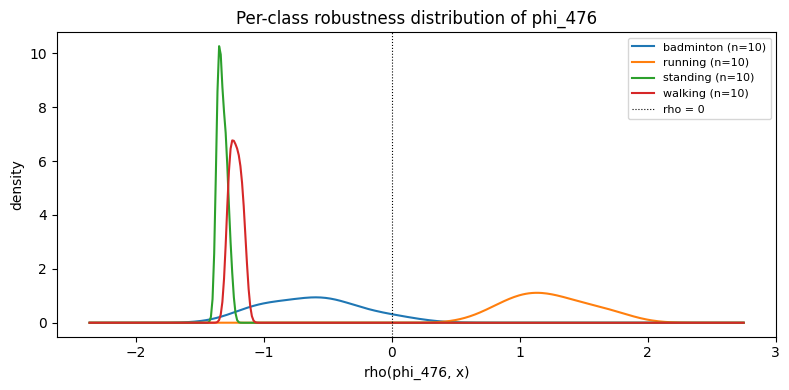

In [287]:
phi = phi_new

# Use the unstandardized tensor that was the model's input feature source.
# X_tr_t is the post-scaler tensor; phi.quantitative expects that input.
rho_train = phi.quantitative(X_tr_t, evaluate_at_all_times=False, normalize=False)
rho_train = rho_train.detach().cpu().numpy().ravel()    # (N_train,)

assert rho_train.shape[0] == len(y_tr), \
    f"shape mismatch: rho has {rho_train.shape[0]} values but y_tr has {len(y_tr)}"

# --- KDE per class -------------------------------------------------------------
classes = np.unique(y_tr)
grid = np.linspace(rho_train.min()-1, rho_train.max()+1, 400)

fig, ax = plt.subplots(figsize=(8, 4))
for c in classes:
    rho_c = rho_train[y_tr == c]
    if rho_c.size < 2 or np.allclose(rho_c.std(), 0):
        # KDE needs variance; fall back to a thin spike at the mean
        ax.axvline(rho_c.mean(), linestyle="--", label=f"{c} (n={rho_c.size}, degenerate)")
        continue
    kde = gaussian_kde(rho_c)
    ax.plot(grid, kde(grid), label=f"{c} (n={rho_c.size})")

# vertical line at robustness = 0 (STL satisfaction boundary)
ax.axvline(0, color="black", linewidth=0.8, linestyle=":", label="rho = 0")

ax.set_xlabel(f"rho(phi_{j}, x)")
ax.set_ylabel("density")
ax.set_title(f"Per-class robustness distribution of phi_{j}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [288]:
import copy
import numpy as np
from collections import defaultdict
from torcheck.stl import And, Or


# ---- helpers ------------------------------------------------------------------

def conjunction(formula_list):
    """Build phi_1 AND phi_2 AND ... AND phi_n as a left-folded And tree."""
    if len(formula_list) == 0:
        raise ValueError("empty conjunction")
    out = formula_list[0]
    for phi in formula_list[1:]:
        out = And(out, phi)
    return out


def disjunction(formula_list):
    """Build phi_1 OR phi_2 OR ... OR phi_n as a left-folded Or tree."""
    if len(formula_list) == 0:
        raise ValueError("empty disjunction")
    out = formula_list[0]
    for phi in formula_list[1:]:
        out = Or(out, phi)
    return out


def global_top_m_indices(W_sel, b, x, class_idx, others, m):
    """Top-m formulas by sum of signed margin contributions across competitors."""
    contrib_matrix = np.stack([(W_sel[class_idx] - W_sel[k]) * x for k in others])  # (K-1, M_sel)
    agg = contrib_matrix.sum(axis=0)
    order = np.argsort(-agg)
    return order[:m].tolist(), contrib_matrix


# ---- per-sample local explanation --------------------------------------------

def local_explanation(x, W_sel, b, model, formulas, non_zero_features,
                      X_tr_t, y_tr, m=3):
    """Build a conjunction-of-reparametrized-formulas explanation for one sample.

    Returns
    -------
    phi_local : Node
        The reparametrized conjunction, ready to evaluate.
    selected_global_indices : list[int]
        Indices into the original `formulas` list (i.e. into the M-dim feature space).
    info : dict
    """
    K = W_sel.shape[0]
    scores = W_sel @ x + b
    class_idx = int(np.argmax(scores))
    target_class = model.classes_[class_idx]
    others = [k for k in range(K) if k != class_idx]

    # Top-m globally by sum of signed margin contributions.
    picked_in_sel, _ = global_top_m_indices(W_sel, b, x, class_idx, others, m)

    # Map indices from the M_sel space back to the M space (formulas list is M-long).
    sel_to_full = np.where(non_zero_features)[0]
    picked_in_full = [int(sel_to_full[j]) for j in picked_in_sel]

    # Reparametrize each picked formula.
    repar_formulas = []
    deltas = []
    for j_full, j_sel in zip(picked_in_full, picked_in_sel):
        weight_j = W_sel[class_idx, j_sel]
        phi_j_new, delta_j, _ = reparametrize_formula(
            formulas[j_full], weight_j, X_tr_t, y_tr, target_class
        )
        repar_formulas.append(phi_j_new)
        deltas.append(delta_j)

    phi_local = conjunction(repar_formulas)
    info = {
        "predicted_class": target_class,
        "picked_full_indices": picked_in_full,
        "deltas": deltas,
    }
    return phi_local, picked_in_full, info


# ---- pipeline over the test set ----------------------------------------------

def build_class_global_explanations(X_te_t, X_te_feats_np, y_te,
                                    W, b, model, formulas, non_zero_features,
                                    X_tr_t, y_tr, m=3, verbose=True):
    """For each predicted class, build a disjunction of per-sample local
    conjunctions over all test samples predicted as that class.

    Returns
    -------
    global_per_class : dict[class_label -> Node]
    locals_per_class : dict[class_label -> list[(test_sample_idx, phi_local, info)]]
    """
    W_sel = W[:, non_zero_features]

    locals_per_class = defaultdict(list)

    n_test = X_te_feats_np.shape[0]
    for i in range(n_test):
        x_i = X_te_feats_np[i, non_zero_features]
        scores = W_sel @ x_i + b
        class_idx = int(np.argmax(scores))
        target_class = model.classes_[class_idx]

        phi_local_i, picked_i, info_i = local_explanation(
            x_i, W_sel, b, model, formulas, non_zero_features,
            X_tr_t, y_tr, m=m,
        )
        locals_per_class[target_class].append((i, phi_local_i, info_i))

        if verbose:
            print(f"sample {i:3d}  pred={target_class:<12s}  "
                  f"picked={picked_i}  deltas={[f'{d:+.3f}' for d in info_i['deltas']]}")

    global_per_class = {
        cls: disjunction([phi for _, phi, _ in lst])
        for cls, lst in locals_per_class.items()
    }
    return global_per_class, locals_per_class

In [289]:
global_per_class, locals_per_class = build_class_global_explanations(
    X_te_t, X_te_feats.numpy(), y_te,
    W=W, b=b, model=model, formulas=formulas, non_zero_features=non_zero_features,
    X_tr_t=X_tr_t, y_tr=y_tr,
    m=3, verbose=True,
)

# Inspect: number of disjuncts (test samples) per class.
for cls, lst in locals_per_class.items():
    print(f"{cls:<12s}: {len(lst):3d} local conjunctions")

# Empirical check of the soundness direction (should be 100% by construction
# if the reparametrization works perfectly, lower if the shift didn't
# fully separate the distributions).
for cls, phi_global in global_per_class.items():
    rho = phi_global.quantitative(X_te_t, evaluate_at_all_times=False, normalize=False)
    rho = rho.detach().cpu().numpy().ravel()
    target_mask = (y_te == cls)
    others_mask = ~target_mask
    print(f"{cls:<12s}  "
          f"frac. {cls} satisfying phi_{cls}_global: {(rho[target_mask] > 0).mean():.1%}   "
          f"frac. others satisfying it (FALSE positives): {(rho[others_mask] > 0).mean():.1%}")

sample   0  pred=standing      picked=[416, 415, 107]  deltas=['+4.494', '-11.065', '+3.140']
sample   1  pred=standing      picked=[416, 415, 107]  deltas=['+4.494', '-11.065', '+3.140']
sample   2  pred=standing      picked=[415, 416, 107]  deltas=['-11.065', '+4.494', '+3.140']
sample   3  pred=standing      picked=[416, 415, 107]  deltas=['+4.494', '-11.065', '+3.140']
sample   4  pred=standing      picked=[416, 415, 107]  deltas=['+4.494', '-11.065', '+3.140']
sample   5  pred=standing      picked=[416, 415, 107]  deltas=['+4.494', '-11.065', '+3.140']
sample   6  pred=standing      picked=[416, 415, 107]  deltas=['+4.494', '-11.065', '+3.140']
sample   7  pred=standing      picked=[416, 415, 107]  deltas=['+4.494', '-11.065', '+3.140']
sample   8  pred=standing      picked=[416, 415, 107]  deltas=['+4.494', '-11.065', '+3.140']
sample   9  pred=standing      picked=[416, 415, 107]  deltas=['+4.494', '-11.065', '+3.140']
sample  10  pred=running       picked=[476, 300, 105]  delta

In [291]:
global_per_class

{np.str_('standing'): <torcheck.stl.Or at 0x7f9c6554a5d0>,
 np.str_('running'): <torcheck.stl.Or at 0x7f9c65548470>,
 np.str_('walking'): <torcheck.stl.Or at 0x7f9c6554bbf0>,
 np.str_('badminton'): <torcheck.stl.Or at 0x7f9c65548110>}

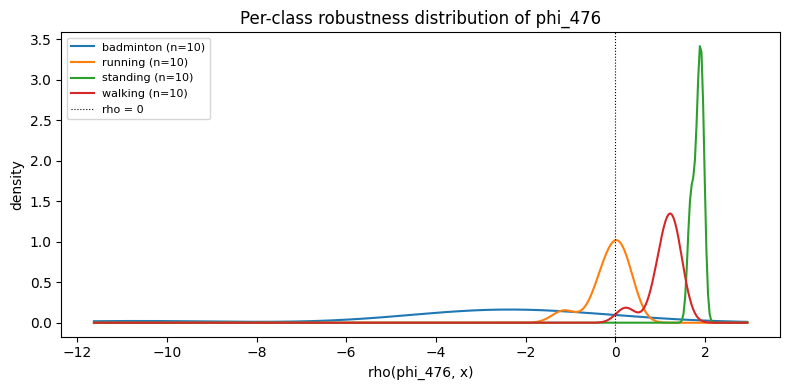

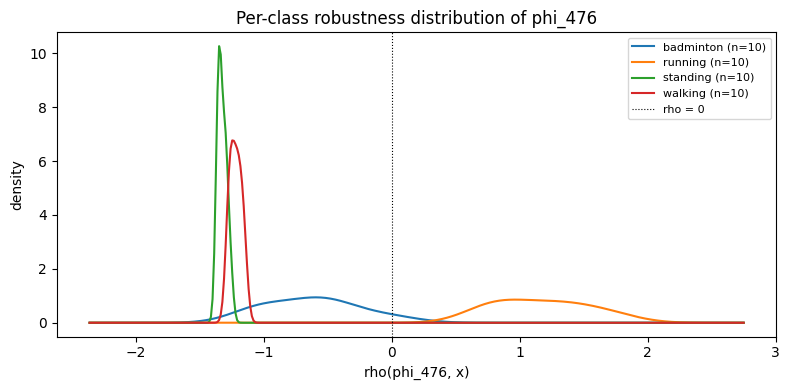

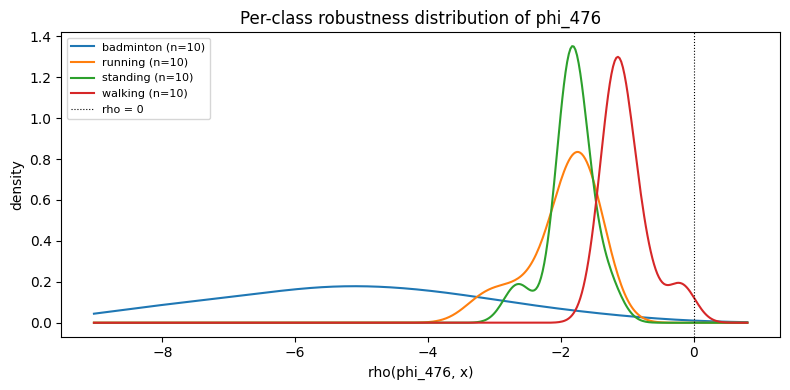

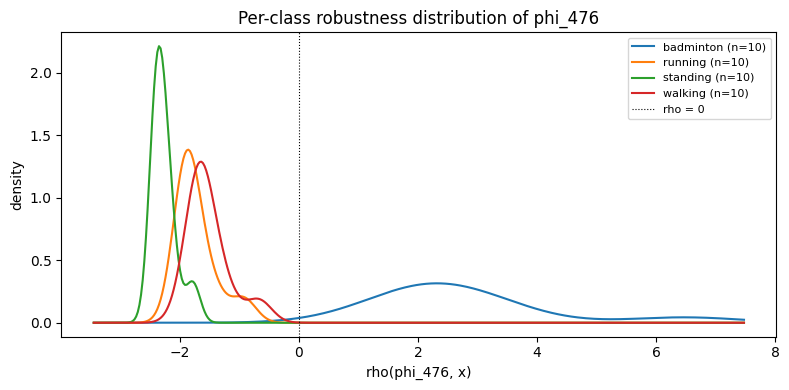

In [294]:
for phi in global_per_class.values():

    # Use the unstandardized tensor that was the model's input feature source.
    # X_tr_t is the post-scaler tensor; phi.quantitative expects that input.
    rho_train = phi.quantitative(X_tr_t, evaluate_at_all_times=False, normalize=False)
    rho_train = rho_train.detach().cpu().numpy().ravel()    # (N_train,)

    assert rho_train.shape[0] == len(y_tr), \
        f"shape mismatch: rho has {rho_train.shape[0]} values but y_tr has {len(y_tr)}"

    # --- KDE per class -------------------------------------------------------------
    classes = np.unique(y_tr)
    grid = np.linspace(rho_train.min()-1, rho_train.max()+1, 400)

    fig, ax = plt.subplots(figsize=(8, 4))
    for c in classes:
        rho_c = rho_train[y_tr == c]
        if rho_c.size < 2 or np.allclose(rho_c.std(), 0):
            # KDE needs variance; fall back to a thin spike at the mean
            ax.axvline(rho_c.mean(), linestyle="--", label=f"{c} (n={rho_c.size}, degenerate)")
            continue
        kde = gaussian_kde(rho_c)
        ax.plot(grid, kde(grid), label=f"{c} (n={rho_c.size})")

    # vertical line at robustness = 0 (STL satisfaction boundary)
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":", label="rho = 0")

    ax.set_xlabel(f"rho(phi_{j}, x)")
    ax.set_ylabel("density")
    ax.set_title(f"Per-class robustness distribution of phi_{j}")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()